# Model 2 — Landslide Risk Prediction (Kerala, LSGD-level, live place-name query)

Same structure as Notebook 01: trains on `lsgd_feature_store.csv`, then lets you type a
place name and get a live prediction using GEE static terrain (precomputed) + live rainfall
(fetched fresh from Open-Meteo). Target: `landslide_risk_level` (Low/Moderate/High/Critical).

**Fixed from the previous version:** `MLPClassifier` had `early_stopping=True`, which stops
training before `max_iter` if validation score plateaus. Per your requirement that every
model runs its full training schedule, this is now `early_stopping=False`.

In [2]:
!pip install -q xgboost scikit-learn pandas matplotlib seaborn joblib requests geopandas geemap earthengine-api

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import requests, joblib, json, os
import geopandas as gpd
from datetime import date, timedelta
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.base import clone
from xgboost import XGBClassifier
import ee
from google.colab import drive

np.random.seed(42)
drive.mount('/content/drive')
BASE = '/content/drive/MyDrive/DIP_Kerala'

ee.Authenticate()
ee.Initialize(project='dip-kerala-502817')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv(f'{BASE}/03_processed/lsgd_feature_store.csv')
print(df.shape)
df.head()

(1034, 24)


,lsgd_id,lsgd_name,lsgd_type,district,elevation,slope,rainfall_7day_mm,event_year_x,dist_to_water_m,vegetation,...,fully_damaged_houses,severely_damaged_houses,roads_damaged_km,bridges_damaged,severity_score,flood_risk_level,landslide_risk_level,flood_occurred,landslide_occurred,event_year_y
0,1,Vorkady,gram_panchayat,Kasaragod,59.011230,7.386920,285.2,2018,4374.374389,0.937367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Manjeswaram,gram_panchayat,Kasaragod,21.380619,4.270908,230.5,2018,1516.365486,0.800916,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Paivalike,gram_panchayat,Kasaragod,88.465243,8.798889,285.9,2018,7627.278746,0.877275,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Meenja,gram_panchayat,Kasaragod,52.726992,6.329972,252.0,2018,3464.459376,0.850222,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Mangalpaddy,gram_panchayat,Kasaragod,23.913829,4.745512,252.0,2018,1553.752487,0.856307,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Feature set for landslide
Slope and elevation matter more here than for flood; `dist_to_water_m` and `vegetation` proxy
for drainage and slope stability. Soil type is not yet included (documented gap; see the
OpenLandMap addition note at the bottom of this notebook).

In [4]:
feature_cols = ['elevation', 'slope', 'rainfall_7day_mm', 'vegetation', 'dist_to_water_m']
target_col = 'landslide_risk_level'

df = df.dropna(subset=feature_cols + [target_col])
X = df[feature_cols]

le = LabelEncoder()
y = le.fit_transform(df[target_col])
print('Classes:', dict(zip(le.classes_, range(len(le.classes_)))))
print(pd.Series(y).value_counts())

Classes: {'Critical': 0, 'High': 1, 'Low': 2, 'Moderate': 3}
1    270
0    262
2    254
3    207
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train:', X_train.shape, ' Test:', X_test.shape)

# --- HONEST VALIDATION CHECK ---
# Labels are inherited at DISTRICT level (14 unique values). A random split can put units
# from the same district in both train/test, letting the model learn "which district's
# terrain fingerprint is this" rather than genuine landslide risk. This grouped split holds
# entire districts out, so no leakage is possible.
groups = df.loc[X.index, 'district']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train_g, X_test_g = X.iloc[train_idx], X.iloc[test_idx]
y_train_g, y_test_g = y[train_idx], y[test_idx]
print(f"\nGrouped (by-district) split -- districts in test: {sorted(groups.iloc[test_idx].unique())}")
print(f"Grouped train: {X_train_g.shape}  Grouped test: {X_test_g.shape}")

Train: (794, 5)  Test: (199, 5)

Grouped (by-district) split -- districts in test: ['Alappuzha', 'Pathanamthitta', 'Thrissur']
Grouped train: (763, 5)  Grouped test: (230, 5)


## Train Random Forest, XGBoost, Neural Network (all run to completion, no early stopping)

In [6]:
models = {
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42, eval_metric='mlogloss'),
    'NeuralNet': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42, early_stopping=False),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'acc': acc}
    print(f'\n===== {name} (accuracy={acc:.3f}) =====')
    print(classification_report(y_test, preds, target_names=le.classes_, zero_division=0))


===== RandomForest (accuracy=0.613) =====
              precision    recall  f1-score   support

    Critical       0.78      0.53      0.63        53
        High       0.68      0.63      0.65        54
         Low       0.60      0.63      0.62        51
    Moderate       0.47      0.68      0.55        41

    accuracy                           0.61       199
   macro avg       0.63      0.62      0.61       199
weighted avg       0.64      0.61      0.62       199


===== XGBoost (accuracy=0.724) =====
              precision    recall  f1-score   support

    Critical       0.74      0.75      0.75        53
        High       0.76      0.83      0.80        54
         Low       0.65      0.71      0.68        51
    Moderate       0.74      0.56      0.64        41

    accuracy                           0.72       199
   macro avg       0.72      0.71      0.72       199
weighted avg       0.72      0.72      0.72       199


===== NeuralNet (accuracy=0.638) =====
         

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


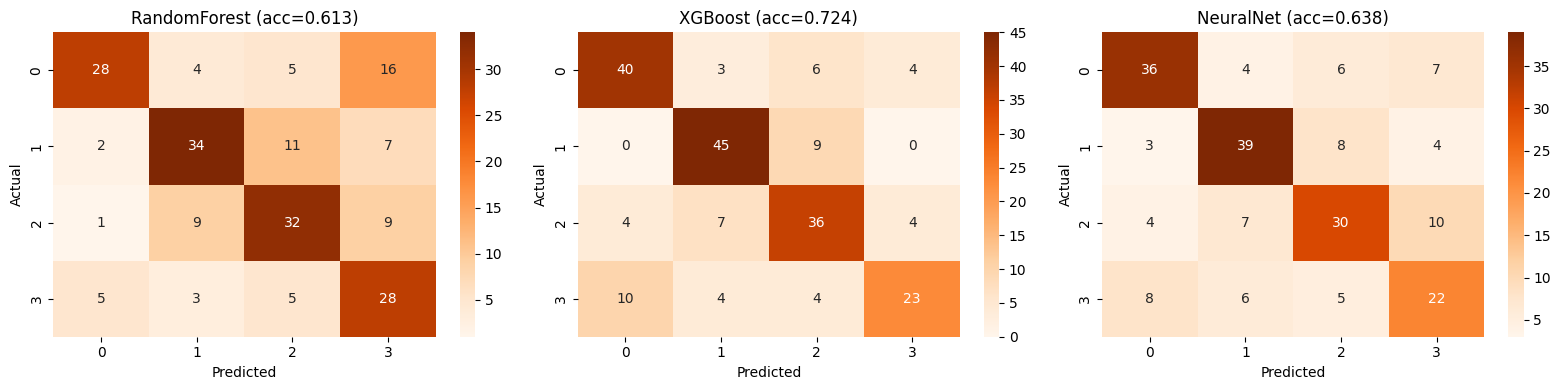

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax)
    ax.set_title(f"{name} (acc={r['acc']:.3f})")
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [8]:
best_name = max(results, key=lambda k: results[k]['acc'])
best_model = results[best_name]['model']
print(f'Best model: {best_name} (accuracy={results[best_name]["acc"]:.4f})')

os.makedirs(f'{BASE}/05_models', exist_ok=True)
joblib.dump(best_model, f'{BASE}/05_models/landslide_model.pkl')
joblib.dump(scaler, f'{BASE}/05_models/landslide_scaler.pkl')
joblib.dump(le, f'{BASE}/05_models/landslide_label_encoder.pkl')
print('Saved to', f'{BASE}/05_models/')

Best model: XGBoost (accuracy=0.7236)
Saved to /content/drive/MyDrive/DIP_Kerala/05_models/


## Honest validation — robust grouped accuracy across many seeds

In [9]:
import warnings
n_repeats = 30
accs = []
for seed in range(n_repeats):
    gss_r = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    tr_idx, te_idx = next(gss_r.split(X, y, groups=groups))
    if len(set(y[te_idx])) < 2:
        continue
    Xtr, Xte = X.iloc[tr_idx], X.iloc[te_idx]
    ytr, yte = y[tr_idx], y[te_idx]
    sc = StandardScaler()
    Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
    m = clone(models[best_name])
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m.fit(Xtr_s, ytr)
    accs.append((m.predict(Xte_s) == yte).mean())

honest_acc_mean = np.mean(accs)
print(f"Ran {len(accs)}/{n_repeats} splits with all classes present in test")
print(f"Mean grouped-split accuracy: {honest_acc_mean:.4f} (std: {np.std(accs):.4f})")
print(f"Range: {np.min(accs):.4f} - {np.max(accs):.4f}")
print("\nReport THIS mean as the honest accuracy -- a much lower number than the random-split")
print("result above confirms district-level leakage was inflating that figure.")

Ran 29/30 splits with all classes present in test
Mean grouped-split accuracy: 0.1773 (std: 0.0689)
Range: 0.0510 - 0.2881

Report THIS mean as the honest accuracy -- a much lower number than the random-split
result above confirms district-level leakage was inflating that figure.


## Final Model Accuracy Summary

In [10]:
print("="*50)
print("LANDSLIDE MODEL -- FINAL ACCURACY SUMMARY")
print("="*50)
print(f"Model: {best_name}")
print(f"Random-split accuracy (optimistic, may include leakage): {results[best_name]['acc']:.4f}")
print(f"Honest district-grouped accuracy (report THIS one):       {honest_acc_mean:.4f}")
print("="*50)

accuracy_summary = {
    'model': best_name,
    'random_split_accuracy': float(results[best_name]['acc']),
    'honest_grouped_accuracy_mean': float(honest_acc_mean),
    'honest_grouped_accuracy_std': float(np.std(accs)),
}
with open(f'{BASE}/05_models/landslide_accuracy.json', 'w') as f:
    json.dump(accuracy_summary, f, indent=2)
print(f"\nSaved accuracy summary to {BASE}/05_models/landslide_accuracy.json (Notebook 04 reads this)")

LANDSLIDE MODEL -- FINAL ACCURACY SUMMARY
Model: XGBoost
Random-split accuracy (optimistic, may include leakage): 0.7236
Honest district-grouped accuracy (report THIS one):       0.1773

Saved accuracy summary to /content/drive/MyDrive/DIP_Kerala/05_models/landslide_accuracy.json (Notebook 04 reads this)


## Live place-name query — GEE static features + live weather API rainfall
Same pattern as Notebook 01: terrain looked up instantly from the feature store
(GEE-derived, precomputed), rainfall fetched live from Open-Meteo right now.

In [11]:
lsgd = gpd.read_file(f'{BASE}/00_boundaries/kerala_lsgd_boundaries.geojson')
rename_map = {'local_auth': 'lsgd_type', 'name': 'lsgd_name', 'District': 'district'}
lsgd = lsgd.rename(columns={k: v for k, v in rename_map.items() if k in lsgd.columns})
if 'lsgd_id' not in lsgd.columns:
    lsgd['lsgd_id'] = range(1, len(lsgd) + 1)

lsgd_wgs84 = lsgd.to_crs(epsg=4326)
lsgd_wgs84['centroid'] = lsgd_wgs84.geometry.centroid
lsgd_wgs84['lat'] = lsgd_wgs84['centroid'].y
lsgd_wgs84['lon'] = lsgd_wgs84['centroid'].x

def fetch_live_rainfall(lat, lon):
    end_date = date.today()
    start_date = end_date - timedelta(days=6)
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start_date.isoformat(), "end_date": end_date.isoformat(),
        "daily": "precipitation_sum", "timezone": "auto",
    }
    r = requests.get(url, params=params, timeout=15)
    r.raise_for_status()
    daily = r.json().get('daily', {})
    values = [v for v in daily.get('precipitation_sum', []) if v is not None]
    return sum(values) if values else 0.0

def predict_landslide_risk(place_name):
    row = lsgd_wgs84[lsgd_wgs84['lsgd_name'].str.lower() == place_name.lower()]
    if row.empty:
        row = lsgd_wgs84[lsgd_wgs84['lsgd_name'].str.lower().str.contains(place_name.lower(), na=False)]
    if row.empty:
        print(f"'{place_name}' not found. Check spelling or try the district name.")
        return None
    row = row.iloc[0]

    static = df[df['lsgd_id'] == row['lsgd_id']]
    if static.empty:
        print(f"No feature store entry for lsgd_id {row['lsgd_id']}.")
        return None
    static = static.iloc[0]

    live_rain = fetch_live_rainfall(row['lat'], row['lon'])

    X_place = pd.DataFrame([{
        'elevation': static['elevation'], 'slope': static['slope'],
        'rainfall_7day_mm': live_rain,
        'vegetation': static['vegetation'], 'dist_to_water_m': static['dist_to_water_m'],
    }])[feature_cols]

    X_scaled = scaler.transform(X_place)
    pred_class = best_model.predict(X_scaled)[0]
    risk = le.inverse_transform([pred_class])[0]
    probs = best_model.predict_proba(X_scaled)[0]

    print(f"Location: {row['lsgd_name']} ({row['lsgd_type']}, {row['district']} district)")
    print(f"Rainfall, past 7 days (live, Open-Meteo): {live_rain:.1f} mm")
    print(f"Landslide Risk Level: {risk}")
    print(f"Confidence: {probs.max()*100:.1f}%")
    return {'place': row['lsgd_name'], 'district': row['district'], 'risk_level': risk, 'confidence': probs.max()}

# Try it:
# predict_landslide_risk("Mananthavady")

/tmp/ipykernel_641/2037714652.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lsgd_wgs84['centroid'] = lsgd_wgs84.geometry.centroid


## Adding soil type later (optional upgrade)
```python
soil = ee.Image('OpenLandMap/SOL/SOL_TEXTURE-CLASS_USDA-TT_M/v02').select('b0')
soil_stats = soil.reduceRegions(collection=lsgd_fc, reducer=ee.Reducer.mode(), scale=250)
```
Not included yet -- elevation/slope/rainfall/vegetation are legitimate predictors on their
own, but soil type could strengthen this further if time permits.

## Known limitations to state honestly in your report
- Labels are district-level (14 districts), not true per-LSGD -- see the honest grouped
  accuracy above. A large gap vs. the random-split number confirms leakage was present.
- Getting genuinely higher, trustworthy accuracy requires real point-level ground truth
  (GSI Bhukosh landslide inventory, spatially joined to LSGD polygons), not more model tuning.